#### Running the place field analysis ####

In [ ]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sl_forgery.analysis.utilities import compute_track_lengths, load_place_field_data
from sl_forgery.analysis.place_cell_analysis import PlaceFieldDetector, PlaceFieldDetectionConfiguration

In [2]:
# Path to the session feather file.
session_path = Path("C:/Users/natal/Downloads/sunlab/chelsea_data/2025-09-16-18-44-32-476061.feather")

# Set trial and fluorescence type.
trial_type = "ABC"
fluorescence_column = "single_day_dff"

track_lengths = compute_track_lengths(session_path=session_path)

track_length = track_lengths[trial_type]
fluorescence, position, speed = load_place_field_data(
    session_path=session_path,
    track_length=track_length,
    fluorescence_column=fluorescence_column,
    trial_type=trial_type,
)

print(f"Track lengths: {track_lengths}")
print(f"Loaded {fluorescence.shape[0]} cells, {fluorescence.shape[1]} frames")

Track lengths: {'ABC': 177.0, 'ABDC': 237.0}
Loaded 3571 cells, 14124 frames


In [ ]:
# Initializes the detector and runs place field detection.
detector = PlaceFieldDetector(
    fluorescence=fluorescence,
    position=position,
    speed=speed,
    track_length=track_length,
    bin_size=2.0,  # Default bin_size=5.0, 2.0 is used for better visualization with jupyter display.
    configuration=PlaceFieldDetectionConfiguration(),
)

place_fields = detector.detect()

print(f"Detected {len(place_fields.centers)} place fields in {np.sum(place_fields.has_place_field)} cells")

# Generates and displays the plot.
title = session_path.stem + (f" ({trial_type})" if trial_type else "")
detector.plot(
    place_fields=place_fields,
    title=title,
)
plt.show()

#### Problems - perhaps further preprocessing needed for the detector? ####

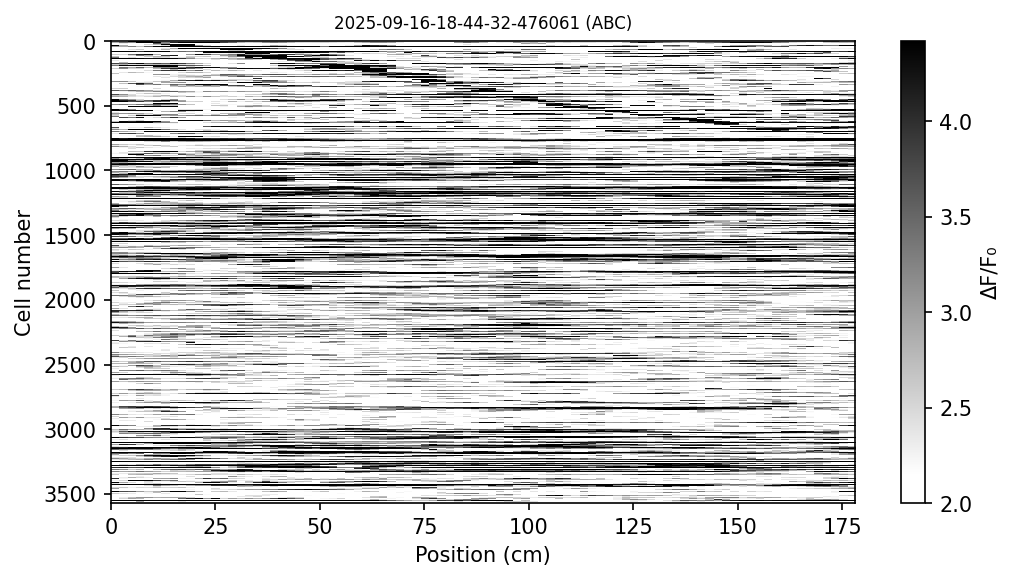

In [4]:
# Plotting all cells instead of place cells only
detector.plot(
    place_fields=place_fields,
    title=title,
    show_only_place_cells=False,
)
plt.show()

For cells showing a high normalized fluorescence across all positions, they could be artifacts since their baseline fluorescence is very low at all positions.

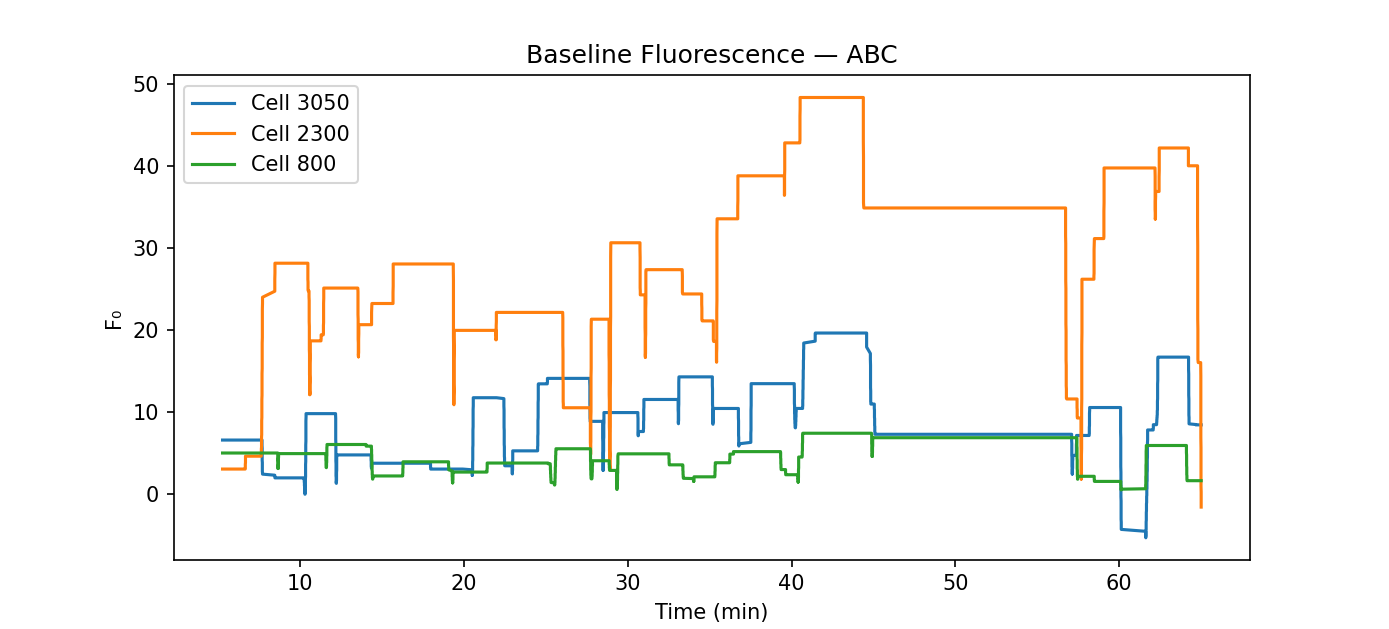

In [8]:
from IPython.display import Image

Image("C:/Users/natal/Downloads/sunlab/figures/baseline_fluorescence.png")